## **SAVE A COPY OF THIS NOTEBOOK TO PUT ANSWERS INTO**

#Part 1 (Reading Assignment), 20 points

**Reminder: there are 5 reading assignments, 3% each for 15% total of your final grade.**

The reading assignment consists of two papers - [one on alignment before fusion](https://arxiv.org/abs/2107.07651), and one on the [Platonic Representation Hypothesis](https://arxiv.org/pdf/2405.07987). Read both papers and then answer the following questions:

1. Explain the implications of 'align before fuse' on your tasks of interest. at which degree, and what type of fusion needs to be performed? And what level of alignment would you need to perform for your data, so that subsequent fusion or representation learning is successful?
2. How can you perform controlled experiments to validate the types of fusion and/or alignment needed for your tasks? What are some challenges you foresee in fusing and aligning your data?
3. Explain the implications of 'platonic representation hypothesis' on your tasks of interest. Do you believe alignment between modalities would automatically emerge as models trained on your data are scaled up?
4. What are some reasons why alignment would not emerge i.e., counter-arguments to the platonic representation hypothesis? You are encouraged to search for follow-up works to the original paper that both support and counter the original arguments.
5. What experiments would you propose to validate the existence and emergence of alignment in your tasks?
6. Can you also think of some downsides of strongly (or perfectly) aligning your data modalities? How can you design experiments to validate that these risks are not present in your trained models?

**Problem #1**

The ‘align before fuse’ paper demonstrates that using unaligned representations from different modalities into a multimodal encoder can be an unnecessarily challenging learning problem. Rather, using contrastive loss to first align the image and text modalities into a shared embedding space, and using this as an input into the multimodal encoder can yield much better results.

The degree of alignment depends on the goal of the machine learning model. For instance, for more course tasks like retrieval-based ones, this only requires a coarse level of alignment. However, if the model’s task requires more detailed reasoning (such as asking a very specific question based on an image), then the alignment should be more fine-grained. The fusion stage will also likely have to be deeper since the model should be able to attend to specific spatial regions that are conditioned on specific words. The type of fusion also matters. For this paper, they use cross-attention, which can express much more information & convey more patterns amongst an image and text queries compared to other fusion methods like concatenation, for instance. much more expressive.
For my own data, I believe that I will need some sort of alignment that is likely early/ medium depth, especially since audio and visual modalities share substantial structure with each other. The alignment and type of fusion are important points of consideration. I need to ensure that the alignment is factoring in the fact that the audio and visual modalities should be close to one another for a particular emotion. I think contrastive loss would be something I definitely want to perform and explore for my data, especially since it’s important that audio-visual pairs that represent the same emotion are being represented close together in space, while different emotions (especially extremely different sentiments) are being pulled apart.

**Problem #2**

In order to validate the types of fusion and the alignment, I can conduct systematic ablation experiments. Essentially, I could train different variations of the model based on doing 1) fusion only with no pre-alignment, 2) alignment only with no fusion encoder, 3) doing alignment and then fusion, and 4) try out different strengths of alignment loss relative to fusion losses. By doing this, I can get a more systemic measure of how important each component is to contributing to a model’s prediction.
In terms of challenges, I think one issue I will run into is handling the noise in modalities and handling the noise between cross-modal interactions. I also think there will likely be information asymmetry amongst the modalities. Specifically, I hypothesize that the vision modality will carry more information than the audio modality, which can cause issues with alignment and may even lead to alignment being worse for the models’ outputs.

**Problem #3**

The idea behind the “platonic representation hypothesis” is that as models grow in size, their internal representations will eventually converge to a model with the same underlying structure, regardless of the modality or the model architecture. For my own project, this hypothesis implies that as long as I make my model really large and train on lots of data, then worrying about alignment across modalities should not be an issue. This is since, naturally, with enough data and training, our model will get to a presentation of the ground truth that is learning the underlying world. I do believe that my modalities will align as the models trained on my data scale up theoretically. However, the problem at hand, specifically with emotion detection, is too nuanced, and I do think in practice, issues will arise. Especially since even just 1 emotion can fluctuate so much across individuals because of their facial expression, or even the context of the emotion or their own cultural upbringing, I believe that finding this ground truth convergence will be very different. Looking at Figure 9 in the paper, information density is also a key factor that impacts alignment, and I believe that the text modality in my dataset is not that dense, which will also lead to making alignment more difficult.


**Problem #4**

There are multiple potential reasons why alignment would not emerge. For one, the paper mentions that if there’s information asymmetry across modalities, then this will cause issues. Another reason mentioned in the paper is sociological bias, where a built-in preference for certain architectures and datasets could lead to convergence, even though the model hasn’t actually learned the ground truth. It’s also argued that convergence doesn’t exist because of too many other factors limiting it, like weight decay breaking it, or converging to saddle points, or also the fact that the training pipeline is too dependent on empirical data from current architectures, which would make this kind of model very hard to generalize to new environments and tasks.

There’s definitely been some counterwork / other research that shows that alignment does not emerge, or there are many issues limiting emergence. For instance, Lampinen et al (https://arxiv.org/html/2507.22216) showed that learned feature representations can be biased to overrepresent certain features and not represent other features enough. This raises the possibility that models are only converging on the easiest features, rather than all of them (potentially missing out on important complex nonlinear features), and these easy features are the ones dominating the models’ predictions. This bias can cause issues because it makes the model seem like we are reaching convergence, however, in actuality, the model is not achieving a deep structural alignment.

**Problem #5**

One experiment I could run is to take pre-trained audio and visual encoders and see how well they are aligned already. I would use my data on both of these encoders and measure cross-modal alignment on the resulting embeddings using some metric such as mutual nearest-neighbors to get pairings of audio and visual. If larger encoder models are showing higher alignment, then this is evidence that, in the grand scheme of things, with enough data and a large enough model, we will reach convergence to a “ground truth of the world”. On the other hand, if we don’t really see alignment improving with model size, then this means that some sort of alignment is needed for the modalities.  

Another experiment I would do is create audio-only and vision-only unimodal models for emotion detection. Then, using the embeddings for these models, I would measure the cross-modal alignment and see how well one model’s embeddings can determine/match the other model’s embeddings, despite each of these models having never seen each other’s modality. This would see if audio and visual embeddings are learning to represent the same emotion (for instance, sadness or anger) in a similar geometric way (and these embeddings might have learned the same underlying structure of reality).

In addition, an experiment I would do is measure alignment separately for each of the seven different emotions in my dataset. I hypothesize that certain emotions, like happiness or anger, will have much higher alignment than other emotions since there would be stronger cross-modal signals that could be detected. On the other hand, other emotions, like contempt, for instance, would have less alignment, as I feel like this is a much more subtle emotion.

**Problem #6**

There are some downsides to strongly aligning data modalities, such as losing potentially important modality-specific information. For instance, take audio and vision modalities. These two modes of data often carry complementary information. Features like pitch, vocal quality, and speech rate can carry important indicators of emotion, however, there is no way that a visual modality can encode that. At the same time, vision modalities also carry important information for which there is no audio equivalent, such as facial feature changes and microexpressions. Forcing perfect alignment for these modalities may cause the model to only learn the shared signals across these 2 modalities, but important information unique to each modality could get dropped.

Another downside to having strong alignment of data modalities is that it makes each modality very brittle to noise. Having them tightly aligned means that any changes in noise or having missing parts of one modality could severely change the fused embedding, which can then severely change the results of the model. Having such a stringent alignment can make the model much less robust to noise.

In terms of experiments, one could measure the accuracy/performance of the model when there is strong modality alignment vs not strong modality alignment. If having strong alignment degrades the model’s performance on taste compared to, for instance, a model that only uses one modality, then that means that important information in a modality is being lost with alignment. Another experiment we could run is testing our model by purposefully removing one modality. We can test our model by zeroing out one modality and seeing how our model degrades. If the model performs extremely badly, then that is a sign that strong alignment is making the model overly dependent on both modalities having to be present.



#Part 2 (Homework Assignment), 100 points

**Reminder: there are 5 homework assignments, 7% each for 35% total of your final grade.**

For this assignment, we will finally begin playing with some of the concepts discussed in the class regarding multimodal modeling.

The first part will deal with Einsum and Tensors.

# Problem 1: Tensors (5 points)

(5 pts) Let's start with tensors. A tensor represents an N-th dimensional array of numbers. In machine learning, they are used to represent data as they can efficiently represent complex data to train with. We traditionally use PyTorch as the package of choice to work with tensors. Fill in the code below with the right tensor operations. Feel free to consult the documentation and the PyTorch tutorials for help.

In [ ]:
import torch
mat_A = torch.rand(3, 2)
mat_B = torch.rand(2, 3)
print(mat_A)
print()
print(mat_B)

tensor([[0.1277, 0.5252],
        [0.1598, 0.9957],
        [0.4848, 0.8642]])

tensor([[0.3693, 0.4124, 0.1954],
        [0.1933, 0.0406, 0.0898]])


In [ ]:
# Common PyTorch operations

# Adding
mat_C = mat_A.T + mat_B #YOUR CODE HERE
print(mat_C)
print()

# Transpose
mat_A_transpose = mat_A.T #YOUR CODE HERE
print(mat_A_transpose)
print()

# Matrix multiplication
mat_mult  = mat_A @ mat_B #YOUR CODE HERE
print(mat_mult)
print()

# Element-wise multiplication
mat_mult_elm = mat_A.T * mat_B #YOUR CODE HERE
print(mat_mult_elm)
print()

# Create a tensor of size (4, 4) of ones
ones = torch.ones(4,4) #YOUR CODE HERE
print(ones)
print()

# Compute mean of A
mean_A = torch.mean(mat_A) #YOUR CODE HERE
print(mean_A)

tensor([[0.4970, 0.5721, 0.6802],
        [0.7185, 1.0363, 0.9540]])

tensor([[0.1277, 0.1598, 0.4848],
        [0.5252, 0.9957, 0.8642]])

tensor([[0.1487, 0.0740, 0.0721],
        [0.2514, 0.1063, 0.1206],
        [0.3461, 0.2350, 0.1723]])

tensor([[0.0472, 0.0659, 0.0947],
        [0.1015, 0.0404, 0.0776]])

tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]])

tensor(0.5262)


# Problem 2: Einsum (5 points)

(10 pts)
Now lets proceed with Einsum. This is a powerful, compact notation used for expressing complex tensor operations on multi-dimensional arrays using a simple string of index labels.

Here is a quick example of using einsum to multiply two matrices.

In [ ]:
A = torch.rand(3, 2)
B = torch.rand(2, 3)

C = torch.einsum('ij,jk->ik', A, B)
print(C)

tensor([[0.9281, 0.2017, 0.7864],
        [0.0261, 0.0098, 0.0099],
        [0.3985, 0.0801, 0.3568]])


The labels provide a shorthand as to what operation to do. Think of the left index as what is before, and the right as to what the dimensions of the final product should look like.

Now use this to do the other possible operations:

In [ ]:
a = torch.rand(3, 1)
b = torch.rand(3, 1)

A = torch.rand(3, 2)
B = torch.rand(2, 3)

# Dot Product of a and b
d_prod = torch.einsum('i, i -> ', a.reshape(-1).double(), b.reshape(-1).double()) #CODE HERE
# converted to .double() to deal with float rounding errors

# Transpose using vector b
transpose = torch.einsum('ij -> ji', b) #CODE HERE

# Summation (element-wise and column-wise of A)
sum_element = torch.einsum('ij->', A.double()) #CODE HERE
sum_column = torch.einsum('ij->j', A.double()) #CODE HERE
# converted to .double() to deal with float rounding errors

# Diagonal of A
n = min(A.shape)
diag = torch.einsum('ii -> i', A[:n,:n]) #CODE HERE

# Outer Product of A and B
outer = torch.einsum('i,j->ij', a.reshape(-1).double(), b.reshape(-1).double()) #CODE HERE
# converted to .double() to deal with float rounding errors

In [ ]:
# Tests to verify that operations were done correctly
def to_list(t):
    return t.detach().cpu().tolist()

def check_dot_product(ans, a, b):
    expected = sum(i * j for i, j in zip(to_list(a), to_list(b)))
    #print(float(ans), float(expected))
    assert float(ans) == float(expected)

def check_transpose(ans, b):
    b_list = to_list(b)
    expected = [[row[i] for row in b_list] for i in range(len(b_list[0]))]
    assert to_list(ans) == expected

def check_sum_element(ans, A):
    expected = sum(val for row in to_list(A) for val in row)
    #print(float(ans) , float(expected) )
    assert float(ans) == float(expected)

def check_sum_column(ans, A):
    A_list = to_list(A)
    expected = [sum(row[i] for row in A_list) for i in range(len(A_list[0]))]
    assert to_list(ans) == expected

def check_concat(ans, A, B):
    expected = to_list(A) + to_list(B)
    assert to_list(ans) == expected

def check_diagonal(ans, A):
    A_list = to_list(A)
    expected = [A_list[i][i] for i in range(len(A_list))]
    assert to_list(ans) == expected

def check_outer_product(ans, a, b):
    a_l, b_l = to_list(a), to_list(b)
    expected = [[i * j for j in b_l] for i in a_l]
    #print(ans, expected)
    assert to_list(ans) == expected

In [ ]:
# Now, we run through all the tests and assure no assertion error is raised!
check_dot_product(d_prod, a.reshape(-1), b.reshape(-1))
check_transpose(transpose, b)
check_sum_element(sum_element, A)
check_sum_column(sum_column, A)
check_diagonal(diag, A[:n, :n])
check_outer_product(outer, a.reshape(-1), b.reshape(-1))

# Problem 3: Unimodal Models (10 points)

We now explore unimodal models and multimodal fusion. For the first part we will work on the image and audio digit dataset AV-MNIST to do digit classification. To benchmark effectiveness, we will use the [Multibench](https://arxiv.org/abs/2107.07502) benchmark. First, we will clone the repo, and get the necessary packages and dataset.

**Note: MAKE SURE YOU SWITCH TO A GPU TO RUN THE MODELS. RUNTIME -> CHANGE RUNTIME TYPE -> T4 GPU (or any other). Be mindful of Google's GPU limits based on what kind of account you own.**

**Also, if you are a student you should be able to have Colab Pro for free if you don't already. Take advantage of that!**

**THIS IS AN EXAMPLE, DO NOT BE RESTRICTED BY WHAT WE DO HERE WHEN YOU HAVE TO IMPLEMENT THIS FOR YOUR OWN DATASET.**

# Getting repo

In [ ]:
!git clone https://github.com/pliang279/MultiBench.git
%cd MultiBench

fatal: destination path 'MultiBench' already exists and is not an empty directory.
/content/MultiBench


# Getting AV-MNIST dataset

In [ ]:
!mkdir data
!pip install gdown
!pip install torch==2.3.1 torchvision==0.18.1 torchtext==0.18.0 torchaudio==2.3.1
!pip install memory_profiler

mkdir: cannot create directory ‘data’: File exists


In [ ]:
!gdown 1KvKynJJca5tDtI5Mmp6CoRh9pQywH8Xp
!tar -xvzf avmnist.tar.gz

Downloading...
From (original): https://drive.google.com/uc?id=1KvKynJJca5tDtI5Mmp6CoRh9pQywH8Xp
From (redirected): https://drive.google.com/uc?id=1KvKynJJca5tDtI5Mmp6CoRh9pQywH8Xp&confirm=t&uuid=1ac0081c-216f-45ea-a684-e042dbbe81f2
To: /content/MultiBench/avmnist.tar.gz
100% 1.60G/1.60G [00:30<00:00, 52.5MB/s]
avmnist/
avmnist/test_labels.npy
avmnist/image/
avmnist/image/train_data.npy
avmnist/image/test_data.npy
avmnist/audio/
avmnist/audio/train_data.npy
avmnist/audio/test_data.npy
avmnist/train_labels.npy
avmnist/avmnist_temp/
avmnist/avmnist_temp/train_labels.npy
avmnist/avmnist_temp/image/
avmnist/avmnist_temp/image/test_data.npy
avmnist/avmnist_temp/image/train_data.npy
avmnist/avmnist_temp/test_labels.npy


In [ ]:
# 1. Path to the folder you untarred
data_dir = '/content/MultiBench/avmnist'

from datasets.avmnist.get_data import get_dataloader
traindata, validdata, testdata  = get_dataloader(data_dir, batch_size=256)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


# Getting packages

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import sys
import os
import torch.optim as optim
from tqdm import tqdm
from unimodals.common_models import GRU, MLP, Sequential, Identity
from training_structures.Supervised_Learning import train, test

We will now start by creating, training, and testing unimodal models for each of the AV-MNIST modalities.

# Audio

In [ ]:
#More conv blocks + BatchNorm
#Dropout2d

class AudioModel(nn.Module):
    def __init__(self, input_dim=12544, hidden_dim=64, dropout_probability=0.2):
        super(AudioModel, self).__init__()
        self.conv = nn.Sequential(
            # Start with a stride of 2 to instantly cut data in half
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1), # 112 -> 56
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),                                     # 56 -> 28

            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), # 28 -> 14
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),                                     # 14 -> 7

            nn.Conv2d(32, 64, kernel_size=3, padding=1), # 7 -> 7
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout2d(dropout_probability),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),  # 7 -> 7
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),                               # 7 -> 3
            nn.Dropout2d(dropout_probability),
            nn.Flatten()
        )
        self.fc = nn.Sequential(
            nn.Linear(128*3*3, 256),
            nn.ReLU(),
            nn.Dropout(dropout_probability),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = x.view(-1, 1, 112, 112)
        return self.fc(self.conv(x))

# Image

In [ ]:
class ImageModel(nn.Module):
    def __init__(self, dropout_prob=0.2):
        super(ImageModel, self).__init__()

        # input: [batch, 1, 28, 28]
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2) # Reduces size by half
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2) # Reduces size by half
        )

        self.block3 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2) # Reduces size by half
        )

        # After 3 poolings: 28 -> 14 -> 7 -> 3
        # Final flattened size: 128 channels * 3 * 3
        self.fc = nn.Sequential(
            nn.Linear(128 * 3 * 3, 128),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)

        # Flatten all dimensions except batch
        x = torch.flatten(x, 1)
        return self.fc(x)

# Training and Testing

We use cross-entropy due to this being a classification task

In [ ]:
import torch.nn as nn
import torch.optim as optim
from torch.amp import autocast, GradScaler

# We use a scalar here to reduce system RAM use (to avoid crashing the session) while not impacting performance.
scaler = GradScaler()

def train_and_test_unimodal(model, train_loader, valid_loader, test_loader, modality_idx, epochs=40, lr=1e-3):
    device = torch.device("cuda")
    model.to(device)

    # Use CrossEntropyLoss for a classification task
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-3)

    best_valid_loss = float('inf')

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2, min_lr=1e-6)

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for batch in train_loader:
            # batch[0] = images, batch[1] = audio
            x = batch[modality_idx].to(device).float()

            # Classification labels must be Long tensors, not Float
            y = batch[2].to(device).long().squeeze()

            optimizer.zero_grad()

            with autocast(device_type='cuda'):
                outputs = model(x)
                loss = criterion(outputs, y)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            train_loss += loss.item()

        # --- Validation Phase ---
        model.eval()
        valid_loss = 0
        correct = 0
        total = 0
        with torch.no_grad():
            for batch in valid_loader:
                x = batch[modality_idx].to(device).float()
                y = batch[2].to(device).long().squeeze()

                outputs = model(x)
                valid_loss += criterion(outputs, y).item()

                _, predicted = torch.max(outputs.data, 1)
                total += y.size(0)
                correct += (predicted == y).sum().item()

        avg_train = train_loss / len(train_loader)
        avg_valid = valid_loss / len(valid_loader)
        accuracy = 100 * correct / total

        scheduler.step(accuracy)

        if avg_valid < best_valid_loss:
            best_valid_loss = avg_valid
            torch.save(model.state_dict(), 'best_avmnist_model.pt')

        print(f"Epoch {epoch}: Train Loss: {avg_train:.4f} | Valid Acc: {accuracy:.2f}%")

    # Final Testing follows the same logic (CrossEntropy + Index 2)
    print("\n--- Final Evaluation Complete ---")
    model.load_state_dict(torch.load('best_avmnist_model.pt'))
    model.eval()
    test_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in test_loader:
            x = batch[modality_idx].to(device).float()
            y = batch[2].to(device).long().squeeze()

            outputs = model(x)
            test_loss += criterion(outputs, y).item()

            _, predicted = torch.max(outputs.data, 1)
            total += y.size(0)
            correct += (predicted == y).sum().item()

        test_accuracy = 100 * correct / total
        test_loss /= len(test_loader)
        print(f"Final Test Loss: {test_loss:.4f} | Test Accuracy: {test_accuracy:.2f}%")

# Training and testing for each modality:

# Audio:

In [ ]:
audio_model = AudioModel()
train_and_test_unimodal(audio_model, traindata, validdata, testdata, modality_idx=1)

Epoch 0: Train Loss: 2.0978 | Valid Acc: 40.24%
Epoch 1: Train Loss: 1.9940 | Valid Acc: 41.04%
Epoch 2: Train Loss: 1.9667 | Valid Acc: 41.82%
Epoch 3: Train Loss: 1.9537 | Valid Acc: 42.04%
Epoch 4: Train Loss: 1.9455 | Valid Acc: 42.10%
Epoch 5: Train Loss: 1.9410 | Valid Acc: 42.20%
Epoch 6: Train Loss: 1.9334 | Valid Acc: 42.24%
Epoch 7: Train Loss: 1.9318 | Valid Acc: 42.24%
Epoch 8: Train Loss: 1.9267 | Valid Acc: 42.20%
Epoch 9: Train Loss: 1.9243 | Valid Acc: 42.20%
Epoch 10: Train Loss: 1.9120 | Valid Acc: 42.20%
Epoch 11: Train Loss: 1.9096 | Valid Acc: 42.20%
Epoch 12: Train Loss: 1.9086 | Valid Acc: 42.20%
Epoch 13: Train Loss: 1.8983 | Valid Acc: 42.16%
Epoch 14: Train Loss: 1.8990 | Valid Acc: 42.20%
Epoch 15: Train Loss: 1.8973 | Valid Acc: 42.20%
Epoch 16: Train Loss: 1.8938 | Valid Acc: 42.20%
Epoch 17: Train Loss: 1.8911 | Valid Acc: 42.20%
Epoch 18: Train Loss: 1.8877 | Valid Acc: 42.20%
Epoch 19: Train Loss: 1.8884 | Valid Acc: 42.20%
Epoch 20: Train Loss: 1.8842 |

# Image:

In [ ]:
image_model = ImageModel()
train_and_test_unimodal(image_model, traindata, validdata, testdata, modality_idx=0)

Epoch 0: Train Loss: 0.9973 | Valid Acc: 66.06%
Epoch 1: Train Loss: 0.9126 | Valid Acc: 68.14%
Epoch 2: Train Loss: 0.8955 | Valid Acc: 68.02%
Epoch 3: Train Loss: 0.8872 | Valid Acc: 68.34%
Epoch 4: Train Loss: 0.8802 | Valid Acc: 69.20%
Epoch 5: Train Loss: 0.8762 | Valid Acc: 68.92%
Epoch 6: Train Loss: 0.8694 | Valid Acc: 69.58%
Epoch 7: Train Loss: 0.8676 | Valid Acc: 69.44%
Epoch 8: Train Loss: 0.8650 | Valid Acc: 69.26%
Epoch 9: Train Loss: 0.8620 | Valid Acc: 68.94%
Epoch 10: Train Loss: 0.8497 | Valid Acc: 69.78%
Epoch 11: Train Loss: 0.8463 | Valid Acc: 70.18%
Epoch 12: Train Loss: 0.8435 | Valid Acc: 69.32%
Epoch 13: Train Loss: 0.8430 | Valid Acc: 69.38%
Epoch 14: Train Loss: 0.8405 | Valid Acc: 70.12%
Epoch 15: Train Loss: 0.8332 | Valid Acc: 70.30%
Epoch 16: Train Loss: 0.8299 | Valid Acc: 70.00%
Epoch 17: Train Loss: 0.8313 | Valid Acc: 69.26%
Epoch 18: Train Loss: 0.8294 | Valid Acc: 69.88%
Epoch 19: Train Loss: 0.8250 | Valid Acc: 69.64%
Epoch 20: Train Loss: 0.8225 |

**ANSWER**

**1. (5 points) Try to get the best performance out of each model by playing around with hyperparameters (hint: you may have to playing around and even add additional arguments to the layers like dropout, look at the documentation and look into how we can improve performace). List the best performance you were able to get and the hyperparameters you used.**


  The best performance I was able to get for each model was:

  - Audio Model:  Final Test Loss: 1.9675 | Test Accuracy: 42.11%

  This was acheived by using AdamW as the optimizer, a ReduceLROnPlateau learning rate scheduler, with epochs = 25 and lr = 1e-3.

  I used 4 convolutional blocks, using BatchNorm to hel with stabilizing training. The last 2 blocks also use dropout to help with regularization and prevent overfitting. I also added a MLP head at the final layer which maps the learned representation to the 10 classes.

  - Image Model: Final Test Loss: 0.8708 | Test Accuracy: 65.24%

  This was acheived by using AdamW as the optimizer, a ReduceLROnPlateau learning rate scheduler, with epochs = 25 and lr = 1e-3.

  I designed 3 convolutional blocks, using BatchNorm to help with stabilizing training. The last layer also uses dropout to help with regularization and prevent overfitting. I also added a fully connected head at the end to map the learned representation to get 10 logits, one for each class.


**2. (5 points) Compare the performances of each modality. What do these suggest to you? What could be done to get the worst performing ones to get closer to the best performing modality/model?**

Looking at the performance of modality, the image model outperforms the audio model. This suggests that the image modality is a more direct, less noisy signal for predicting digits than the audio modality. This could mean that the task itself is simply easier to solve using images, and/or it could also mean that the audio modality has more variability (such as bad mics or just lots of background noise for instance). To get the audio modality (worst performing ones) to closer to the best perfoming modality, we would work on improving the preprocessing of the modality. For instance, is the current way we've decided to embed the audio the best choice?  Are there better normalization choices, or better spectrogram parameter choices we can make?

**Baseline**

Audio
- Epoch 0: Train Loss: 2.1281 | Valid Acc: 37.74%
- Epoch 1: Train Loss: 2.0156 | Valid Acc: 39.78%
- Epoch 2: Train Loss: 1.9926 | Valid Acc: 40.66%
- Epoch 3: Train Loss: 1.9808 | Valid Acc: 40.48%
- Epoch 4: Train Loss: 1.9714 | Valid Acc: 41.42%

--- Final Evaluation Complete ---
- Final Test Loss: 2.0224 | Test Accuracy: 40.22%


Image
- Epoch 0: Train Loss: 1.1160 | Valid Acc: 66.78%
- Epoch 1: Train Loss: 0.9419 | Valid Acc: 68.22%
- Epoch 2: Train Loss: 0.9238 | Valid Acc: 67.56%
- Epoch 3: Train Loss: 0.9142 | Valid Acc: 67.64%
- Epoch 4: Train Loss: 0.9084 | Valid Acc: 69.10%

--- Final Evaluation Complete ---
- Final Test Loss: 0.8936 | Test Accuracy: 64.42%

# Problem 4: Multimodal Fusion (10 points)

Now you will play with multimodal fusion. Lets use a late fusion to improve our performance. We have provided some code with the hyperparameters to consider, but you are encouraged to play with them to try to get improvments. To make things simpler, the encoders for both modalities have been provided. However, some other parts are missing, so you will have to fill those in!

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
from unimodals.common_models import MLP
from fusions.common_fusions import MultiplicativeInteractions2Modal, Concat
from training_structures.Supervised_Learning import train

# Image Encoder
class ImageEncoder(nn.Module):
  def __init__(self, output_dim=64):
      super().__init__()
      self.conv = nn.Sequential(
          nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
          nn.MaxPool2d(2),
          nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
          nn.MaxPool2d(2),
          nn.Flatten(),
          nn.Linear(64 * 7 * 7, output_dim)
      )
  def forward(self, x):
      return self.conv(x)

# Audio Encoder
class AudioEncoder(nn.Module):
  def __init__(self, output_dim=64):
      super().__init__()
      self.conv = nn.Sequential(
          nn.Conv2d(1, 32, 3, stride=2, padding=1), nn.BatchNorm2d(32), nn.ReLU(), # 112 -> 56
          nn.MaxPool2d(2), # 56 -> 28
          nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.BatchNorm2d(64), nn.ReLU(), # 28 -> 14
          nn.Flatten(),
          nn.Linear(64 * 14 * 14, output_dim)
      )
  def forward(self, x):
      return self.conv(x)

# TODO: Encoders - create the list of encoders, images should be first, then audio
encoders = [ImageEncoder(), AudioEncoder()] # CODE HERE

# TODO: Use the concat fusion as the fusion of choice
fusion = Concat() # CODE HERE

# TODO: Create the head, which learns the joint features.
# This should be an MLP that takes with input size based
# on output size of your concationation, a hidden layer of size 256, and output layer
# of size 10.

head = MLP(128, 256, 10) # YOUR CODE

# Run Training
print("Starting Training...")
train(encoders, fusion, head, traindata, validdata, 5,
      task="classification", optimtype=torch.optim.AdamW, is_packed=False,
      lr=5e-4, save='avmnist_lmf.pt', weight_decay=0.001,
      objective=torch.nn.CrossEntropyLoss())

# Run Test
model = torch.load('avmnist_lmf.pt').cuda()
test(model, testdata, 'avmnist', is_packed=False, task="classification",
      criterion=torch.nn.CrossEntropyLoss(), no_robust=True)

Starting Training...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Epoch 0 train loss: tensor(0.9043, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 0 valid loss: tensor(0.7465, device='cuda:0') acc: 0.72
Saving Best


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Epoch 1 train loss: tensor(0.7618, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 1 valid loss: tensor(0.7179, device='cuda:0') acc: 0.7338
Saving Best


...

Epoch 3 train loss: tensor(0.6885, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 3 valid loss: tensor(0.7249, device='cuda:0') acc: 0.7298


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Epoch 4 train loss: tensor(0.6570, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 4 valid loss: tensor(0.7368, device='cuda:0') acc: 0.7298
Training Time: 60.53949499130249
Training Peak Mem: 8658.43359375
Training Params: 1077258


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


acc: 0.6976
Inference Time: 3.5102148056030273
Inference Params: 1077258


**ANSWER**

**1. (2 points) Sometimes when training you may notice the model gets stuck in a range of loss and never seems to get it's loss down. What does this suggest? What are some ways you can fix this?**

This means that the model is not effectively learning. For instance, the learning rate might be too low or too high and its entered a flat region. In order to fix this, we could use a learning rate scheduler. We could also try to improve regularization by incoporating things like dropout or weight decay, or improve stabiliziation with batch normalization.

**2. (2 points) What are some other fusion methods we could use that we could use? Would they lead to improvements compared to early fusion?**

In the model above, we used late stage fusion, where we combined the two models' results together and trained a MLP on top of that. We also could have fused the modalities together at a different stage, such as at the very beginning at the input. Instead of concatenating, we also could have implemented other types of fusion, such as gating, low-rank, or attention-based fusion.  These might have lead to improvement compared to early fusion, especially since the audio modality seems to be more noisy, and these different types of fusion can help deal with differing noise levels. However, it could also add unneccessary complexity and overparameterize the model.

**3. (6 points) Explain the difference between early fusion techniques and late fusion techniques. Be sure to discuss their benefits and tradeoffs.**

Early fusion is where we combine modalities at the start, like at the input level. This stage of fusion is good at capturing cross-modal interactions well, however, it also can be very hard to do well if modalities are noisy / missing. On the other hand, late fusion is where we combine modalities at the end, like by combining logits of a model. This type of fusion is typically more robust if certain modalities are noisy / missing. However, a tradeoff is that with late stage fusion, it may miss out or fail to capture fine-grained interactions amongst different modalities.  

# Problem 5: Other Fusion Techniques (30 points)

Now, we want you to try implementing some of these fusion techniques on your dataset! For this part, you will implement these fusion techniques:
1. Early fusion
2. Late fusion
3. TensorFusion
4. Low-Rank Tensor (LMF) Fusion


**You cannot just import and use the functions available in Multibench to do this. In addition, use einsum where applicable. TO RECIEVE FULL CREDIT, THE FUSIONS YOU IMPLEMENTATION MUST WORK WITH THE DATASET YOU CREATED FROM HOMEWORK 1. YOU WILL HAVE TO CREATE A SIMPLE MODEL FOR EACH FUSION TECHNIQUE TO PLAY WITH.**

**(5 points)** In your write up, report the best validation accuracies of your multimodal model (don't forget to include what hyperparameters you included) after training and any modifications that had to be done to your data or model to be able to train on it. In addition, talk about which technique you believe would be best for your dataset and why that is.

**Design the fusion classes with the modalities you are specifically working with in mind. The example we worked through above with MOSI was meant as a showcase of fusion in action - we do not require you to use text, video and audio as the modalities. Use whichever ones you are working with!**

The code below provided is to be filled in with the models you set up for each technique. For an example, the first fusion technique has been done for you.

**Answer Here:**

In [ ]:
# Imports incase you need them again! Feel free to include anything else you need
import torch
from torch import nn
from torch.nn import functional as F
import pdb
from torch.autograd import Variable
from torch.utils.data import DataLoader, random_split

import h5py
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import time
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path = "/content/drive/MyDrive/mosei.hdf5"
f = h5py.File(path, "r")

print(list(f.keys()))

for key in f.keys():
  print(len(f[key]))

['All Labels', 'COVAREP', 'OpenFace_2', 'words']
23248
23248
23248
23248


The CMU-MOSEI dataset includes four modality groups, each with 23248 items (each a sentence utterance). So far, this is consistent with our goal of having each modality synchronized by time because there is equal amount of items in each group.

For one segment --qXJuDtHPw[0]:

- Text: words[t] for t=1..22
- Audio: COVAREP[t, :] for t=1..22
- Visual: OpenFace_2[t, :] for t=1..22
- Label: y[0, :] in R^7

In [ ]:
for key in f.keys():
  print()
  print(f"== {key} ==")
  group = f[key] # the dataset group for current modality

  first = list(group.keys())[0]  # first subkey in list of subkeys
  print(f"first segment: {first}")
  obj = group[first]
  print(f"obj: {obj}")
  print(f"obj type: {type(obj)}")
  inner = list(obj.keys())
  print(f"inner keys: {inner}")
  for k in inner:
    print(type(obj[k]))
    print(f"ex inner dataset: '{k}', shape: {obj[k].shape}, dtype: {obj[k].dtype}")


== All Labels ==
first segment: --qXJuDtHPw[0]
obj: <HDF5 group "/All Labels/--qXJuDtHPw[0]" (1 members)>
obj type: <class 'h5py._hl.group.Group'>
inner keys: ['features']
<class 'h5py._hl.dataset.Dataset'>
ex inner dataset: 'features', shape: (1, 7), dtype: float32

== COVAREP ==
first segment: --qXJuDtHPw[0]
obj: <HDF5 group "/COVAREP/--qXJuDtHPw[0]" (1 members)>
obj type: <class 'h5py._hl.group.Group'>
inner keys: ['features']
<class 'h5py._hl.dataset.Dataset'>
ex inner dataset: 'features', shape: (22, 74), dtype: float32

== OpenFace_2 ==
first segment: --qXJuDtHPw[0]
obj: <HDF5 group "/OpenFace_2/--qXJuDtHPw[0]" (1 members)>
obj type: <class 'h5py._hl.group.Group'>
inner keys: ['features']
<class 'h5py._hl.dataset.Dataset'>
ex inner dataset: 'features', shape: (22, 713), dtype: float32

== words ==
first segment: --qXJuDtHPw[0]
obj: <HDF5 group "/words/--qXJuDtHPw[0]" (1 members)>
obj type: <class 'h5py._hl.group.Group'>
inner keys: ['features']
<class 'h5py._hl.dataset.Dataset'>

We note that shape of vision, audio, and text modalities are all correspond with number of words (22 words). For instance, (22,74) with COVAREP means the audio feature vector for each word has size 74. This means time steps can be simply broken into words. Labels are different because there is only one label per item.

This means for simple data extraction we can use `f[modality][segment]["features"][:]` which has size (num_timesteps, num_features)

In [ ]:
for segment in list(group.keys())[:5]:
  print(f['All Labels'][segment]['features'][:])

[[1.        0.6666667 0.        0.        0.        0.        0.       ]]
[[1.        0.6666667 0.6666667 0.        0.        0.        0.6666667]]
[[0.6666667 0.        0.        0.        0.        0.        0.       ]]
[[0.         0.6666667  0.6666667  0.         0.         0.
  0.33333334]]
[[0.         0.33333334 0.33333334 0.         0.         0.
  0.        ]]


In [ ]:
for segment in list(group.keys())[:1]:
  print(f['COVAREP'][segment]['features'][:])

[[ 1.27918602e+02  8.83720934e-01  5.40499240e-02 ... -2.86068380e-01
  -2.32127383e-01 -2.20859170e-01]
 [ 1.17934784e+02  3.91304344e-01  4.75775562e-02 ... -3.40750337e-01
  -3.35689932e-01 -2.92199522e-01]
 [ 1.14295456e+02  1.00000000e+00  5.01790680e-02 ... -2.95454383e-01
  -3.06168050e-01 -2.50269294e-01]
 ...
 [ 1.09236839e+02  6.57894731e-01  5.10160215e-02 ... -3.84941965e-01
  -3.34304780e-01 -2.84340858e-01]
 [ 1.08666664e+02  3.96825403e-01  4.19194028e-02 ... -3.74864995e-01
  -3.80066395e-01 -3.45019728e-01]
 [ 1.00811829e+02  2.90322572e-01  7.64665902e-02 ... -4.33147997e-01
  -3.87138933e-01 -3.61659139e-01]]


In [ ]:
for segment in list(group.keys())[:1]:
  print(f['OpenFace_2'][segment]['features'][:])

[[ 0.         23.28336     0.8907143  ...  0.          0.
   0.        ]
 [ 0.         23.6         0.89428574 ...  0.          0.
   0.        ]
 [ 0.         23.816624    0.93       ...  0.          0.
   0.125     ]
 ...
 [ 0.         29.050001    0.90916675 ...  0.          0.
   0.        ]
 [ 0.         29.533316    0.9089473  ...  0.          0.
   0.        ]
 [ 0.         30.300001    0.95413774 ...  0.          0.
   0.        ]]


In [ ]:
for segment in list(group.keys())[:1]:
  print(f['words'][segment]['features'][:])

[[b'writer']
 [b'sp']
 [b'i']
 [b'see']
 [b'that']
 [b'a']
 [b'writer']
 [b'is']
 [b'somebody']
 [b'who']
 [b'has']
 [b'an']
 [b'incredible']
 [b'command']
 [b'of']
 [b'mechanics']
 [b'sp']
 [b'of']
 [b'the']
 [b'english']
 [b'language']
 [b'sp']]


Labels are annotated as such:
[sentiment, happiness, sadness, anger, fear, disgust, surprise].

Each sentence is annotated for sentiment on a [-3,3]
Likert scale of:
[−3: highly negative, −2 negative,
−1 weakly negative, 0 neutral, +1 weakly positive,
+2 positive, +3 highly positive].

In [ ]:
class MOSEIH5Dataset(Dataset):
    def __init__(self, h5_path, modalities=("COVAREP", "OpenFace_2"), label_key="All Labels", target="sentiment"):
        self.target = target

        with h5py.File(h5_path, "r") as f:
            segs = set(f[label_key].keys())
            for m in modalities:
                segs &= set(f[m].keys())
            segments = sorted(list(segs))

            # Compute normalization stats from a subset
            means, stds = {}, {}
            for m in modalities:
                all_feats = []
                for seg in segments[:2000]:
                    arr = f[m][seg]["features"][:]
                    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
                    all_feats.append(arr)
                all_feats = np.concatenate(all_feats, axis=0)
                means[m] = torch.tensor(all_feats.mean(axis=0), dtype=torch.float32)
                stds[m] = torch.tensor(all_feats.std(axis=0) + 1e-8, dtype=torch.float32)

            # Pre-load everything into memory
            self.data = []
            for seg in segments:
                xs = []
                for m in modalities:
                    t = torch.tensor(f[m][seg]["features"][:], dtype=torch.float32)
                    t = torch.nan_to_num(t, nan=0.0, posinf=0.0, neginf=0.0)
                    t = (t - means[m]) / stds[m]
                    xs.append(t)

                y = torch.tensor(f[label_key][seg]["features"][:], dtype=torch.float32).squeeze(0)
                y = torch.nan_to_num(y, nan=0.0, posinf=0.0, neginf=0.0)

                if self.target == "sentiment":
                    y = y[0]
                elif self.target != "all7":
                    raise ValueError("target must be sentiment or all7")

                self.data.append((xs, y))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

Before we do fusion, we first need to create an encoding for the modalitie. We  will learn a projection (D → H) for each modality, so that each modlaity will be mapped into a comparable space and can then be properly fused. I coded up the below encoder, ModalityEncoder, for this.

In [ ]:
class ModalityEncoder(nn.Module):
  """
  converts from [B, T, D] to [B,H]
  """
  def __init__(self, in_dim, hid_dim = 64, dropout = 0.2):
    super().__init__()
    self.proj = nn.Sequential(
        nn.Linear(in_dim, hid_dim),
        nn.ReLU(),
        nn.Dropout(dropout),
    )
    self.out = nn.Sequential(
        nn.Linear(hid_dim, hid_dim),
        nn.ReLU(),
    )

  def forward(self, x):
    x = self.proj(x)          # [B,T,H]
    x = x.mean(dim=1)         # mean pool over words -> [B,H]
    x = self.out(x)           # [B,H]
    return x

# Early Fusion

We fuse together the audio and vision modality at the beginning.

In [ ]:
class EarlyFusion(nn.Module):
  def __init__(self, hid_dim=32, num_outputs=1, dropout=0.2):
    super().__init__()
    self.audio_encoder = ModalityEncoder(74, hid_dim, dropout)
    self.vision_encoder = ModalityEncoder(713, hid_dim, dropout)
    self.proj = nn.Linear(hid_dim * hid_dim, num_outputs)

  def forward(self, x):
    audio_z = self.audio_encoder(x[0]) # [B,H]
    vision_z = self.vision_encoder(x[1]) # [B,H]
    T = torch.einsum('bi, bj-> bij', audio_z, vision_z) # [B,H,H]
    return self.proj(T.reshape(T.size(0), -1)) # [B,num_outputs]

# (5 Points) Late Fusion

After each modality (audio and vision) predicts a logit, we then fuse these logits together at the end.

In [ ]:
class LateFusion(nn.Module):
  def __init__(self, hid_dim=64, num_outputs=1, dropout=0.2):
    super().__init__()
    self.audio_encoder = ModalityEncoder(74, hid_dim, dropout)
    self.vision_encoder = ModalityEncoder(713, hid_dim, dropout)
    self.audio_head = nn.Linear(hid_dim, num_outputs)
    self.visual_head = nn.Linear(hid_dim, num_outputs)
    self.alpha = nn.Parameter(torch.zeros(2))

  def forward(self, x):
    logits = []
    logits.append(self.audio_head(self.audio_encoder(x[0])))
    logits.append(self.visual_head(self.vision_encoder(x[1]))) # [B,num_outputs]
    L = torch.stack(logits, dim=0)                  # [2,B,num_outputs]
    w = F.softmax(self.alpha, dim=0)                # [2]
    return torch.einsum('m,mbc->bc', w, L)          # [B,num_outputs]

# (5 points) Tensor Fusion

In [ ]:
class TensorFusion(nn.Module):
  def __init__(self, hid_dim=32, num_outputs=1, dropout=0.2):
    super().__init__()
    self.audio_encoder = ModalityEncoder(74, hid_dim, dropout)
    self.vision_encoder = ModalityEncoder(713, hid_dim, dropout)
    flat_dim = (hid_dim + 1) ** 2
    self.head = nn.Linear(flat_dim, num_outputs)

  def forward(self, x):
    audio_z = self.audio_encoder(x[0]) # [B,H]
    vision_z = self.vision_encoder(x[1]) # [B,H]
    B = audio_z.size(0)

    z = [audio_z, vision_z]
    zhat = [torch.cat([zi, torch.ones(B, 1, device=zi.device, dtype=zi.dtype)], dim=1) for zi in z] # each is [B,H+1]
    T = torch.einsum('bi,bj->bij', zhat[0], zhat[1]) # [B,H+1,H+1]

    return self.head(T.reshape(B, -1))

# (5 Points) Low-Rank Tensor Fusion (LMF) Fusion

In [ ]:
import torch
import torch.nn as nn

class LMFFusion(nn.Module):
  def __init__(self, hid_dim=64, rank=4, fused_dim=64, num_outputs=1, dropout=0.2):
      super().__init__()
      self.rank = rank
      self.fused_dim = fused_dim

      self.audio_enc = ModalityEncoder(74, hid_dim, dropout)
      self.vision_enc = ModalityEncoder(713, hid_dim, dropout)

      self.audio_factor = nn.Parameter(torch.randn(rank, hid_dim + 1, fused_dim) * 0.02) # [R, (H+1), F]
      self.vision_factor = nn.Parameter(torch.randn(rank, hid_dim + 1, fused_dim) * 0.02) # [R, (H+1), F]

      self.bias = nn.Parameter(torch.zeros(fused_dim))
      self.head = nn.Linear(fused_dim, num_outputs)

  def forward(self, x):
      audio_z = self.audio_enc(x[0])    # [B,H]
      vision_z = self.vision_enc(x[1])  # [B,H]
      B = audio_z.size(0)

      ones_a = torch.ones(B, 1, device=audio_z.device, dtype=audio_z.dtype)
      ones_v = torch.ones(B, 1, device=vision_z.device, dtype=vision_z.dtype)

      audio_zhat = torch.cat([audio_z, ones_a], dim=1)   # [B,H+1]
      vision_zhat = torch.cat([vision_z, ones_v], dim=1) # [B,H+1]

      # project to rank space
      proj_a = torch.einsum('bd,rdh->brh', audio_zhat, self.audio_factor) #[B,R,F]
      proj_v = torch.einsum('bd,rdh->brh', vision_zhat, self.vision_factor) #[B,R,F]

      fused = (proj_a * proj_v).sum(dim=1) + self.bias # [B,F]

      return self.head(fused) # [B,num_outputs]

# Now let's train our models!

In [ ]:
def mosei_collate(batch):
    """
    helps pad input if input modality is ever < 22
    """
    xs_list, ys = zip(*batch)  # xs_list: tuple of lists, ys: tuple of labels

    # separate modalities
    audio_seqs  = [x[0] for x in xs_list]  # each: [T, 74]
    vision_seqs = [x[1] for x in xs_list]  # each: [T, 713]

    # pad along time dimension to the max T in the batch
    audio_pad  = pad_sequence(audio_seqs,  batch_first=True, padding_value=0.0)
    vision_pad = pad_sequence(vision_seqs, batch_first=True, padding_value=0.0)

    y = torch.stack([yy if torch.is_tensor(yy) else torch.tensor(yy) for yy in ys])
    return [audio_pad, vision_pad], y

In [ ]:
dataset = MOSEIH5Dataset(path,modalities=("COVAREP", "OpenFace_2"),target="sentiment")

n = len(dataset)
n_train = int(0.8 * n)
n_val = n - n_train
train_ds, val_ds = random_split(dataset, [n_train, n_val])

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=2, pin_memory=True,collate_fn=mosei_collate)
val_loader   = DataLoader(val_ds, batch_size=64, shuffle=False, num_workers=2, pin_memory=True, collate_fn=mosei_collate)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [ ]:
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def train_and_track(model, train_loader, val_loader, device, epochs=10, lr=1e-3):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)

    train_losses, val_losses, val_accs = [], [], []
    best_val_mse = float('inf')
    best_val_acc = 0.0
    torch.cuda.reset_peak_memory_stats(device)
    start_time = time.time()

    for epoch in range(1, epochs + 1):
        # train
        model.train()
        total_loss, n = 0.0, 0
        for x_list, y in train_loader:
            x_list = [x.to(device) for x in x_list]
            y = y.to(device).float().view(-1, 1)
            pred = model(x_list)
            loss = F.mse_loss(pred, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * y.size(0)
            n += y.size(0)
        train_losses.append(total_loss / n)

        # validatoin
        model.eval()
        total_loss, n = 0.0, 0
        correct, total = 0, 0
        with torch.no_grad():
            for x_list, y in val_loader:
                x_list = [x.to(device) for x in x_list]
                y = y.to(device).float().view(-1, 1)
                pred = model(x_list)
                loss = F.mse_loss(pred, y)
                total_loss += loss.item() * y.size(0)
                n += y.size(0)

                # Binary accuracy: positive vs negative sentiment
                correct += ((pred > 0).float() == (y > 0).float()).sum().item()
                total += y.size(0)

        val_mse = total_loss / n
        val_acc = 100.0 * correct / total
        val_losses.append(val_mse)
        val_accs.append(val_acc)

        if val_mse < best_val_mse:
            best_val_mse = val_mse
        if val_acc > best_val_acc:
            best_val_acc = val_acc

        print(f"  epoch {epoch:02d} | train MSE {train_losses[-1]:.4f} | val MSE {val_mse:.4f} | val Acc {val_acc:.2f}%")

    elapsed = time.time() - start_time
    peak_mem = torch.cuda.max_memory_allocated(device) / (1024 ** 2)

    print(f"  Best val MSE: {best_val_mse:.4f} | Best val Acc: {best_val_acc:.2f}%")

    return {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "val_accs": val_accs,
        "best_val_mse": best_val_mse,
        "best_val_acc": best_val_acc,
        "time": elapsed,
        "peak_mem_mb": peak_mem,
        "params": sum(p.numel() for p in model.parameters() if p.requires_grad),
    }


models = {
    "EarlyFusion":  EarlyFusion(),
    "LateFusion":   LateFusion(),
    "TensorFusion": TensorFusion(),
    "LMFFusion":    LMFFusion(),
}

In [ ]:
EPOCHS = 10
results = {}

for name, model in models.items():
    print(f"\n{'='*50}\nTraining {name}...")
    res = train_and_track(model, train_loader, val_loader, device, epochs=EPOCHS)
    results[name] = res
    print(f"  Params: {res['params']:,} | Time: {res['time']:.1f}s | Peak Mem: {res['peak_mem_mb']:.1f} MB")


Training EarlyFusion...
  epoch 01 | train MSE 0.8867 | val MSE 0.9352 | val Acc 63.68%
  epoch 02 | train MSE 0.8811 | val MSE 0.9318 | val Acc 64.00%
  epoch 03 | train MSE 0.8670 | val MSE 0.9221 | val Acc 64.80%
  epoch 04 | train MSE 0.8582 | val MSE 0.9145 | val Acc 64.97%
  epoch 05 | train MSE 0.8498 | val MSE 0.9166 | val Acc 65.05%
  epoch 06 | train MSE 0.8488 | val MSE 0.8985 | val Acc 65.63%
  epoch 07 | train MSE 0.8473 | val MSE 0.9274 | val Acc 65.74%
  epoch 08 | train MSE 0.8745 | val MSE 0.9033 | val Acc 65.08%
  epoch 09 | train MSE 0.8327 | val MSE 0.8931 | val Acc 65.38%
  epoch 10 | train MSE 0.8200 | val MSE 0.9293 | val Acc 64.15%
  Best val MSE: 0.8931 | Best val Acc: 65.74%
  Params: 28,385 | Time: 101.1s | Peak Mem: 116.0 MB

Training LateFusion...
  epoch 01 | train MSE 1.1376 | val MSE 1.0784 | val Acc 60.34%
  epoch 02 | train MSE 1.0384 | val MSE 1.0167 | val Acc 62.99%
  epoch 03 | train MSE 1.0055 | val MSE 1.0041 | val Acc 63.98%
  epoch 04 | train M

**(5 points) In your write up, report the best validation accuracies of your multimodal model (don't forget to include what hyperparameters you included) after training and any modifications that had to be done to your data or model to be able to train on it. In addition, talk about which technique you believe would be best for your dataset and why that is.**

**ANSWER**

The best validation accuracy was achieved by early fusion, getting an accuracy of 65.74% for validation. The other models (late fusion, tensor fusion, and low-rank tensor fusion) got 64.86, 63.89, and 63.76 respectively.

For evaluating the model, I used MSE loss for sentiment regression, and to get an accuracy, I turned this problem into binary accuracy (predicting positive vs. negative sentiment).

The hyperparameters that I used to train were an Adaom optimizer with learning rate = 1e-3 and weight decay of 1e-5. I used 10 epochs, and a batch size of 64. These were applied to all 4 of the different fusion models.

In order to prepare the data to be able to trained, I had to standardize the modalitiy features. I also had to add padding to ensure all sequences were the same length (22). In order to prepare the data to be fused, I also had to create a new encoder class, called ModalityEncoder, which essentially takes a batch of an embedding (ex: a batch of the audio data) and turns them to a fixed size, which allows me to fuse the differing modalities together since they all have their own size.

I believe that early fusion would be best for my dataset, since it performed the best out of the different fusion methods we tried. Since my audio and visual modalities are temporally aligned, I believe that early fusion is able to exploit this fine-grained alignment and get better predicts as a result of this. It does not need to force each modality to make its own prediction, which late fusion does / succeeds well in when the modalites are more weakly related. However, audio and vision go hand in hand, so early fusion is the best choice here.

(10 points) In addition, create some visualizations of the following for each fusion:

* Number of parameters for each model (unimodal and multimodal)
* Memory Use
* Time until convergence

You are free to plot them here or through other means (like wandb). After doing so, discuss what are the pros and cons of unimodal versus multimodal models.

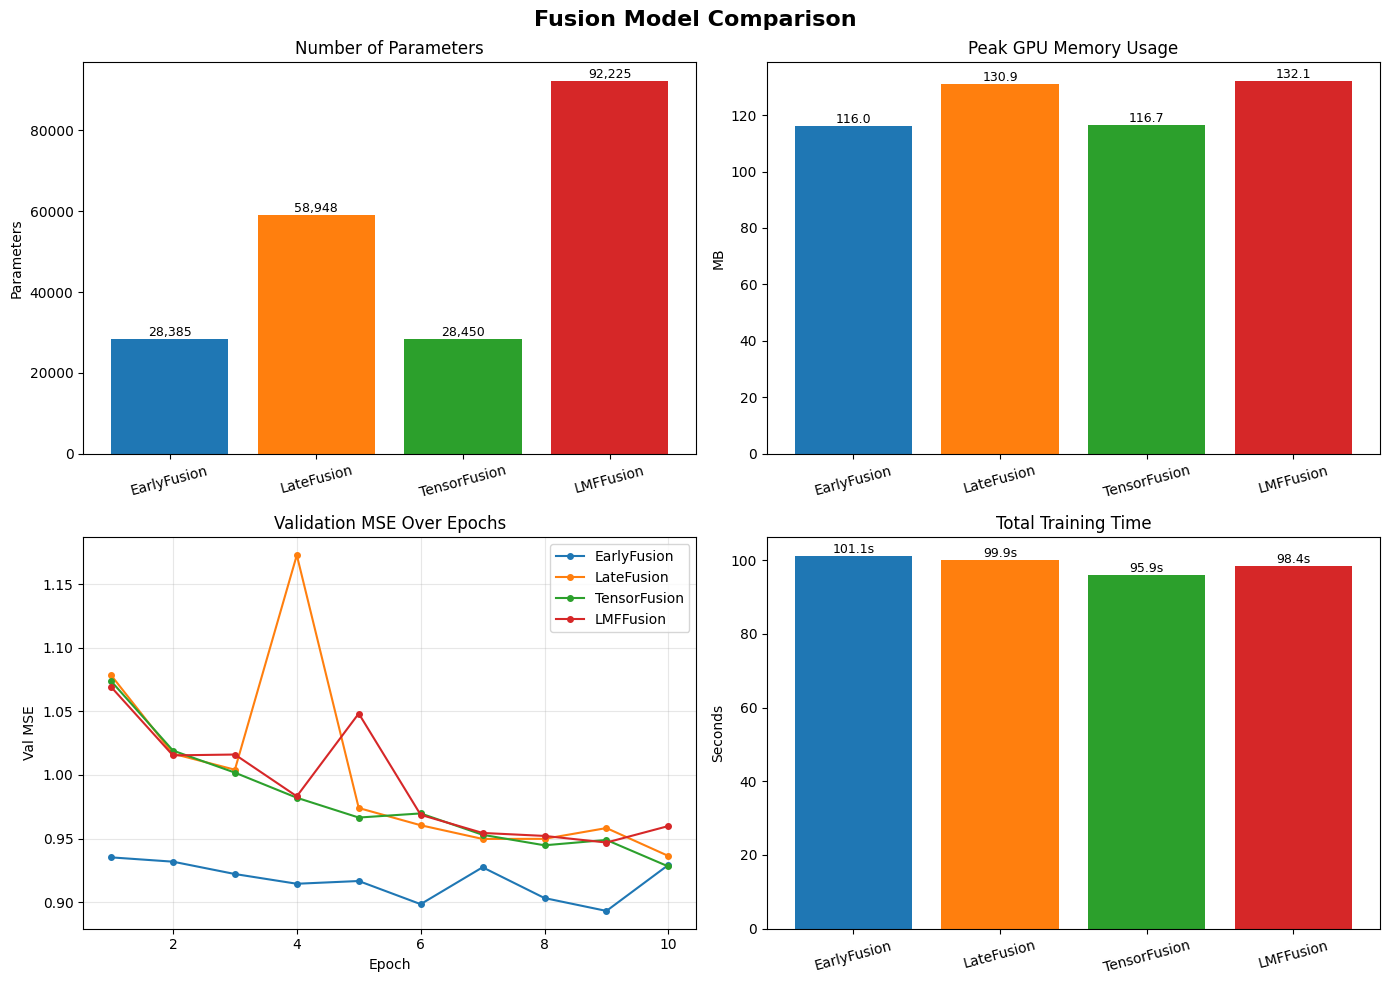

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Fusion Model Comparison", fontsize=16, fontweight="bold")
names = list(results.keys())
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

# parameter count
ax = axes[0, 0]
params = [results[n]["params"] for n in names]
bars = ax.bar(names, params, color=colors)
ax.set_title("Number of Parameters")
ax.set_ylabel("Parameters")
for bar, p in zip(bars, params):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{p:,}', ha='center', va='bottom', fontsize=9)
ax.tick_params(axis='x', rotation=15)

# gpu memory
ax = axes[0, 1]
mems = [results[n]["peak_mem_mb"] for n in names]
bars = ax.bar(names, mems, color=colors)
ax.set_title("Peak GPU Memory Usage")
ax.set_ylabel("MB")
for bar, m in zip(bars, mems):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{m:.1f}', ha='center', va='bottom', fontsize=9)
ax.tick_params(axis='x', rotation=15)

# convergence curves
ax = axes[1, 0]
for name, color in zip(names, colors):
    ax.plot(range(1, EPOCHS+1), results[name]["val_losses"], label=name, color=color, marker='o', markersize=4)
ax.set_title("Validation MSE Over Epochs")
ax.set_xlabel("Epoch")
ax.set_ylabel("Val MSE")
ax.legend()
ax.grid(True, alpha=0.3)

# training time
ax = axes[1, 1]
times = [results[n]["time"] for n in names]
bars = ax.bar(names, times, color=colors)
ax.set_title("Total Training Time")
ax.set_ylabel("Seconds")
for bar, t in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{t:.1f}s', ha='center', va='bottom', fontsize=9)
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

**ANSWER**

Unimodal models use just one source of information, which makes them much easier to train in terms of speed and also cost since there's less parameters. You also don't have to worry about aligning different modalities together, which can often improve model results since adding an extra modality can harm performance. A con, however, is that unimodal models can leave out key missing information since its only focusing on one singular modality. Also, if that one modality has missing data or is very noisy, then the model will likely have worse performance since there are no other modalities to rely on.

Multimodal models incorporate multiple modalities together, which can improve model accuracy and performance since having different modalities means the model can incoporate different types of information in order to make a better prediction. Additionally, when one modality is missing or has a lot of noise, the model can still perform quite well by using other modalities to make up for the missing/noisy data. On the other hand, having more modalities though means that there are more parameters in the model. This means these models are typically more costly and also harder to train. Dealing with multiple modalities also means having to deal with differing input shapes and deal with choosing how to fuse them, which also add more complexity.


# Problem 6: Contrastive Learning (30 points)

For the next part of this HW, we will focus on contrastive learning. As a reminder, contrastive learning is a local, discrete alignment method used in machine learning. To explore this, we look at [CLIP](https://arxiv.org/pdf/2103.00020), a multimodal model developed by OpenAI that uses contrastive learning to align visual and textual data together.

**THIS IS JUST AN EXAMPLE, DO NOT LET THIS RESTRICT THE IMPLEMENTATION YOU WILL BE DOING.**

In [ ]:
!pip install ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.0 MB/s eta 0:00:00
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-nc0sw56x
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-nc0sw56x
  Resolved https://github.com/openai/CLIP.git to commit ded190a052fdf4585bd685cee5bc96e0310d2c93
  Preparing metadata (setup.py) ... done
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=2e51934178ef38d043ebe3f4cf9667232b547bc3603ed8fcb075fb375ff77294
  Stored in directory: /tmp/pip-ephem-wheel-cache-dnmflewo/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


In [ ]:
# Packages to import
import transformers
import torch
import clip
from PIL import Image
import requests
from io import BytesIO

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


First, we create the model.

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Loading CLIP on {device}...")
model, preprocess = clip.load("ViT-B/32", device=device)

Loading CLIP on cuda...


100%|████████████████████████████████████████| 338M/338M [00:01<00:00, 188MiB/s]


Next, we will load an image to use. Note that we cannot use the MOSI dataset - we need to use raw data and the data points from the dataset already have extracted features. Upload a picture of someone smiling to use for this example (you can just find one online, save it and add to here).

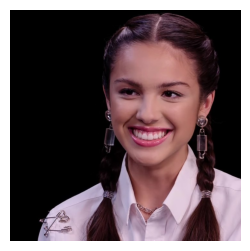

In [ ]:
image_filename = "/content/drive/MyDrive/olivia_rodrigo_smile.jpg" # REPLACE WITH YOUR FILE
image = Image.open(image_filename).convert("RGB")

plt.figure(figsize=(3, 3))
plt.imshow(image)
plt.axis("off")
plt.show()

Now, we will prepare the prompt to use.

In [ ]:
# Options to pick from
text_options = ["a photo of a sad person", "a photo of a happy person", "a photo of an angry person"]
image_input = preprocess(image).unsqueeze(0).to(device)
text_inputs = clip.tokenize(text_options).to(device)

Now, let's run the inference and get the results!

In [ ]:
with torch.no_grad():
    image_features = model.encode_image(image_input)
    text_features = model.encode_text(text_inputs)

    # Normalize features
    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features /= text_features.norm(dim=-1, keepdim=True)

    # Calculate similarity (Dot Product)
    similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)
    values, indices = similarity[0].topk(3)

print(f"\nImage classified against: {text_options}")
print("-" * 30)
for value, index in zip(values, indices):
    print(f"{text_options[index]:>30s}: {100 * value.item():.2f}%")


Image classified against: ['a photo of a sad person', 'a photo of a happy person', 'a photo of an angry person']
------------------------------
     a photo of a happy person: 97.66%
       a photo of a sad person: 1.37%
    a photo of an angry person: 0.99%


(10 pts) We will now create, train and run zero-shot classification using contrastive learning for your own dataset. Fill in the missing information below for a generalize contrastive learning model. The training and zero-shot classification functions have been provided to you, through you may need to make slight modifications based on your dataset setup. **Design the model keeping in mind the modalities that you are specifically using. THE CLIP EXAMPLE ABOVE IS JUST TO SHOW CONTRASTIVE LEARNING IN ACTION - WE ARE NOT REQUIRING THAT YOU USE TEXT AND IMAGE AS THE MODALITIES OF CHOICE.** Try various queries, projectors, and settings on your dataset!

**You must use einsum where applicable.**


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch.utils.data import Dataset, DataLoader
import h5py

In [ ]:
# General model implementation for contrastive learning
class CLModel(nn.Module):
  def __init__(self, dim_x1, dim_x2, embedded_dim, temp):
    # TODO:
    # 1. Create Encoders for modalities
    # 2. Create a projector, which maps specific modality dimensions to a shared space.
    #     do this for each modality. (hint: fusions!)
    # 3. Create learnable temperature (this has already been done for you)

    # 1.
    super().__init__()

    self.encoder_audio = nn.Sequential(
        nn.Linear(dim_x1, embedded_dim),
        nn.ReLU(),
        nn.Dropout(0.2),
    )
    self.encoder_vision = nn.Sequential(
        nn.Linear(dim_x2, embedded_dim),
        nn.ReLU(),
        nn.Dropout(0.2),
    )


    # 2.
    self.projector_audio =  nn.Sequential(
        nn.Linear(embedded_dim, embedded_dim),
        nn.ReLU(),
        nn.Linear(embedded_dim, embedded_dim),
    )
    self.projector_vision = nn.Sequential(
        nn.Linear(embedded_dim, embedded_dim),
        nn.ReLU(),
        nn.Linear(embedded_dim, embedded_dim),
    )

    # 3.
    self.scale = nn.Parameter(torch.ones([]) * np.log(1/temp))

  def forward(self, x1, x2):
    # TODO:
    # 1. Extract the raw features
    # 2. Project them to the embedding space
    # 3. Normalize vectors and return

    # YOUR CODE HERE
    h1 = self.encoder_audio(x1)
    h1 = h1.mean(dim=1)
    h2 = self.encoder_vision(x2)
    h2 = h2.mean(dim=1)

    z1 = self.projector_audio(h1)
    z2 = self.projector_vision(h2)

    return F.normalize(z1), F.normalize(z2)

# Contrastive loss. This pulls positives together and pulls negatives apart
class ContrastiveLoss(nn.Module):
  def __init__(self, model):
    # TODO: Initialize model and loss function as cross entropy loss
    super().__init__()

    self.model = model
    self.loss_fn = nn.CrossEntropyLoss()

  def forward(self, x1_emb, x2_emb, scale):
    # TODO:
    # 1. Get the batch size (hint: you can get this
    #    from the dimensions of your embedded space)
    # 2. Create similarity matrix using einsum
    # 3. Create labels (hint: the coorect match for index i is label i)
    # 4. Compute Symmetric loss (loss amongst rows + loss amongst columns)/2
    batch_size = x1_emb.size(0)

    scale = scale.exp()
    logits = torch.einsum('id, jd -> ij', x1_emb, x2_emb) * scale

    labels = torch.arange(batch_size, device=x1_emb.device)

    loss_rows = self.loss_fn(logits, labels)
    loss_cols = self.loss_fn(logits.T, labels)
    return (loss_rows + loss_cols) / 2

In [ ]:
import torch.optim as optim
# Training function
def train_model(model, contrastive_loss, dataloader, num_epochs=5, learning_rate=3e-4, device='cpu'):

    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    model.to(device)
    model.train()
    print(f"Starting training for {num_epochs} epochs...")

    for epoch in range(num_epochs):
        epoch_loss = 0.0

        for batch_idx, (data_a, data_b) in enumerate(dataloader):
            data_a, data_b = data_a.to(device), data_b.to(device)

            optimizer.zero_grad()

            emb_a, emb_b = model(data_a, data_b)

            loss = contrastive_loss(emb_a, emb_b, model.scale)

            loss.backward()

            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(dataloader)
        print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {avg_loss:.4f}")

In [ ]:
# After training, we can now do zero-shot prediction
@torch.no_grad()
def predict_best_match(model, query_input, candidate_inputs, device):
    model.eval()

    query_feat = model.encoder_a(query_input.unsqueeze(0).to(device))
    query_emb = F.normalize(model.projector_a(query_feat), dim=1)

    cand_feat = model.encoder_b(candidate_inputs.to(device))
    cand_emb = F.normalize(model.projector_b(cand_feat), dim=1)

    scores = torch.einsum('id, jd -> ij', query_emb, cand_emb)

    best_match_idx = scores.argmax().item()

    print(f"Best match: {best_match_idx} with score {scores[0, best_match_idx].item()}")

    return best_match_idx, scores

In [ ]:
class MOSEIContrastiveDataset(Dataset):
    def __init__(self, base_dataset):
        self.base = base_dataset

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        xs, y = self.base[idx]
        return xs[0], xs[1]  # audio, vision

def cl_collate(batch):
    audio_seqs, vision_seqs = zip(*batch)
    audio_pad = pad_sequence(audio_seqs, batch_first=True, padding_value=0.0)
    vision_pad = pad_sequence(vision_seqs, batch_first=True, padding_value=0.0)
    return audio_pad, vision_pad


cl_train_ds = MOSEIContrastiveDataset(train_ds)
cl_val_ds = MOSEIContrastiveDataset(val_ds)
cl_train_loader = DataLoader(cl_train_ds, batch_size=64, shuffle=True, num_workers=0, pin_memory=True, collate_fn=cl_collate)

In [ ]:
model = CLModel(dim_x1=74, dim_x2=713, embedded_dim=128, temp=0.07)
contrastive_loss = ContrastiveLoss(model)
train_model(model, contrastive_loss, cl_train_loader, num_epochs=10, learning_rate=3e-4, device=device)

Starting training for 10 epochs...
Epoch [1/10] | Loss: 3.1229
Epoch [2/10] | Loss: 2.4001
Epoch [3/10] | Loss: 2.0323
Epoch [4/10] | Loss: 1.7702
Epoch [5/10] | Loss: 1.5701
Epoch [6/10] | Loss: 1.4140
Epoch [7/10] | Loss: 1.2773
Epoch [8/10] | Loss: 1.1620
Epoch [9/10] | Loss: 1.0885
Epoch [10/10] | Loss: 0.9932


Now answer some of these questions:

1. (5 points) Any suprising results from using this on your dataset?
2. (5 points) Typically, cross-entropy loss is used in this contrastive learning, why is this the case?
3. (10 points) Create some visual examples of the data post alignment. Can you point out samples where the alignment worked and where it failed? Why do you suspect that is?

**ANSWER**

**Question 1)**

 One suprising result was just seeing how well the contrastive loss converged, despiste audio and vision being quite different modalities. Especially since there was no explicit label supervision, I was not expecting the model to perform as well as it did. Based on the loss dropping to around 1.0 by the end, it seems that the model was able to somewhat learn a meaningful shared space between the 2 modalities, which I doubted espeically since the dimensionalities of the 2 modalities were so different in size too.

**Question 2)**

Cross-entropy loss is used in contrastive learning since the goal behind contrastive learning can be reframed as a classification problem, which makes CEL a perfect loss to use. With this type of problem,for our model we've created, basically once we are given an audio sample, the model has to determine the correct matching vision sample. Cross-entropy is used here since it can serve as a softmax and weight the correct pair high but also rank incorrect pairs low, allwoing the model to learn and get better at determining the correct matching audio-vision sample.

**Question 3)**

Looking at the visual plots created of the data post alignment, we can see some instances where alignment worked and also where it failed. Looking at the t-SNE plot with the audio (blue circles) and vision modalities (orange triangles) projected into a 2D space, we can see that many pairs have short gray lines, which means that their embeddings are close together. This is especially true in the upper area of teh graph, showing that contrastive loss was able to successful connect these audio-vision embeddings together. On the other hand, there are also some pairs with long grey lines stretching the entire width of the plot. These long lines are instances of alignment failures. These are likely instances where one of the modalities was noisy or not helpful, which meant that  contrastive learning was unable to connect the audio-vision pairing together.

Looking at the cosine similarities of the matched pairs (and stratifying it based on correctly matched vs. wrong matched in green vs. red), we can see that the green bars are much taller than red, meaning than th emodel is reliably detecting some underlying pattern to correctly match up the audio and vision pairs together. There are definitley a few samples (in red) where the bars are negative, which means that these samples are dissimilar to other samples, on average. I suspect that these might be the case where the audio and vision embeddings do not share much fine-grained information, meaning that these pairs are harder to match.

In [ ]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

model.eval()
model.to(device)

with torch.no_grad():
    audio_batch, vision_batch = next(iter(cl_train_loader))
    audio_batch, vision_batch = audio_batch.to(device), vision_batch.to(device)
    audio_emb, vision_emb = model(audio_batch, vision_batch)

    sim_matrix = torch.einsum('id, jd -> ij', audio_emb, vision_emb).cpu().numpy()

B = audio_emb.size(0)

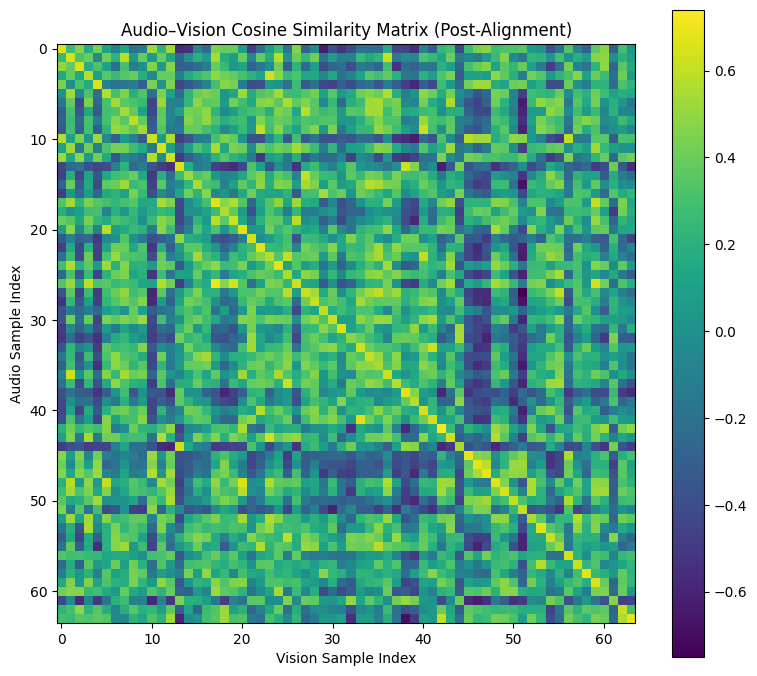

In [ ]:
# similiarty matrix
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(sim_matrix, cmap='viridis')
ax.set_xlabel("Vision Sample Index")
ax.set_ylabel("Audio Sample Index")
ax.set_title("Audio–Vision Cosine Similarity Matrix (Post-Alignment)")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

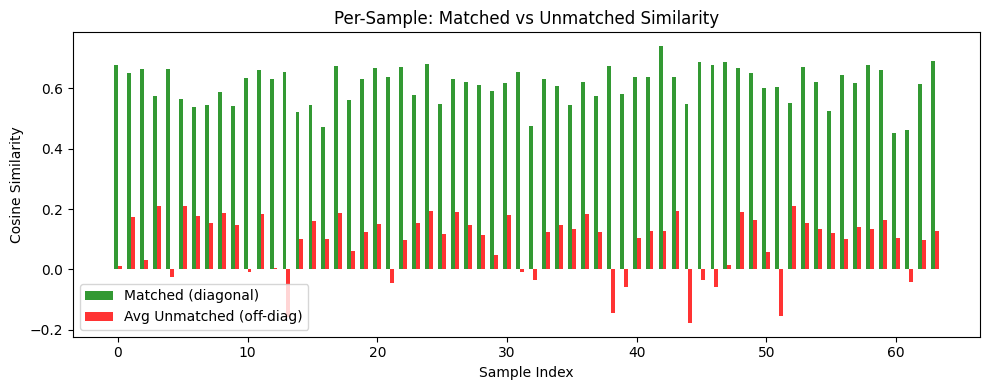

In [ ]:
# per-sample diagonal scores vs off-diag
diag_scores = np.diag(sim_matrix)  # matched pairs
off_diag_means = (sim_matrix.sum(axis=1) - diag_scores) / (B - 1)  # avg unmatched

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(B)
ax.bar(x - 0.15, diag_scores, width=0.3, label="Matched (diagonal)", color="green", alpha=0.8)
ax.bar(x + 0.15, off_diag_means, width=0.3, label="Avg Unmatched (off-diag)", color="red", alpha=0.8)
ax.set_xlabel("Sample Index")
ax.set_ylabel("Cosine Similarity")
ax.set_title("Per-Sample: Matched vs Unmatched Similarity")
ax.legend()
plt.tight_layout()
plt.show()

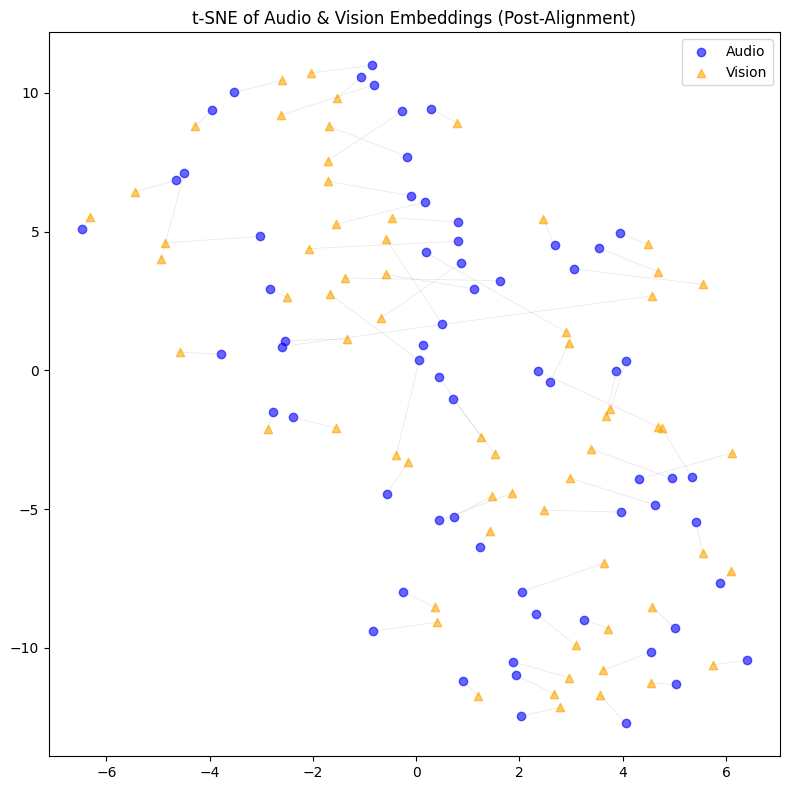

In [ ]:
# t-SNE of both modalties in shared space
audio_np = audio_emb.cpu().numpy()
vision_np = vision_emb.cpu().numpy()

combined = np.concatenate([audio_np, vision_np], axis=0)
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
coords = tsne.fit_transform(combined)

audio_coords = coords[:B]
vision_coords = coords[B:]

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(audio_coords[:, 0], audio_coords[:, 1], c='blue', marker='o', alpha=0.6, label='Audio')
ax.scatter(vision_coords[:, 0], vision_coords[:, 1], c='orange', marker='^', alpha=0.6, label='Vision')

# draw lines that connect matched pairs
for i in range(B):
    ax.plot([audio_coords[i, 0], vision_coords[i, 0]],
            [audio_coords[i, 1], vision_coords[i, 1]],
            color='gray', alpha=0.2, linewidth=0.5)

ax.set_title("t-SNE of Audio & Vision Embeddings (Post-Alignment)")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# get best / worst aligned
gaps = diag_scores - off_diag_means
best_idxs = np.argsort(gaps)[-5:]   # top 5 best
worst_idxs = np.argsort(gaps)[:5]   # top 5 worst

print("Best Aligned Samples: ")
for i in best_idxs:
    print(f"  Sample {i}: matched sim = {diag_scores[i]:.3f}, avg unmatched = {off_diag_means[i]:.3f}, gap = {gaps[i]:.3f}")

print("\nWorst Aligned Samples: " )
for i in worst_idxs:
    print(f"  Sample {i}: matched sim = {diag_scores[i]:.3f}, avg unmatched = {off_diag_means[i]:.3f}, gap = {gaps[i]:.3f}")

Best Aligned Samples: 
  Sample 44: matched sim = 0.547, avg unmatched = -0.177, gap = 0.724
  Sample 46: matched sim = 0.678, avg unmatched = -0.057, gap = 0.734
  Sample 51: matched sim = 0.606, avg unmatched = -0.154, gap = 0.761
  Sample 13: matched sim = 0.653, avg unmatched = -0.158, gap = 0.812
  Sample 38: matched sim = 0.674, avg unmatched = -0.146, gap = 0.820

Worst Aligned Samples: 
  Sample 52: matched sim = 0.550, avg unmatched = 0.211, gap = 0.340
  Sample 60: matched sim = 0.452, avg unmatched = 0.105, gap = 0.348
  Sample 5: matched sim = 0.566, avg unmatched = 0.212, gap = 0.354
  Sample 6: matched sim = 0.538, avg unmatched = 0.177, gap = 0.361
  Sample 3: matched sim = 0.575, avg unmatched = 0.209, gap = 0.366


# Problem 7: Reflection (10 points)

Now we'll take some time to reflect on this homework. Take some time to discuss the following:

1. (5 points) What concept did you find the most interesting?
2. (5 points) Which concepts (if any) do you see being useful towards your goal? Why? If there was none, discuss why.
3. (0 points, optional) Is there a topic that was discussed during lectures up to the release of the assignment that you wished was covered in the homework? Any from the assignment that you wanted there to be touched upon more? Any feedback you have in general for homeworks or the class?

**ANSWER**

1) The concept I found the most interesting was the einsum tensor math. I didn't realize that we could easily do matrix math like this, and it honestly makes dealing with dimensions of matrices so much easier. I've always struggled with concatenating matrices in the past, especially dealing with dimension mismatches and concatenation axes. Hence, I was really excited to learn and work with einsum tools with this pset.

2) I definitely find the different methods of fusion to be really useful to my final project. The whole premise of my final project is trying to find the optimal point of fusion depth based on missing modalities / noisy modalities. I didn't realize that there were so many different ways to fuse modalities together beyond just the stage (so like early vs late). I will definitely be exploring other fusion methods like tensor and low-rank.